# Relationship Bench — Results Analysis

Comparative analysis of LLM classification outputs across all models run against the 91-post filtered dataset.

Each model was asked to classify a r/relationship_advice post into one of six categories:
**End Relationship · Communicate · Give Space / Time · Set / Respect Boundaries · Seek Therapy / Counselling · Compromise**


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path
from itertools import combinations

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

CATEGORIES = [
    "End Relationship",
    "Communicate",
    "Give Space / Time",
    "Set / Respect Boundaries",
    "Seek Therapy / Counselling",
]
SHORT = {
    "End Relationship":          "End Rel.",
    "Communicate":               "Communicate",
    "Give Space / Time":         "Give Space",
    "Set / Respect Boundaries":  "Boundaries",
    "Seek Therapy / Counselling":"Therapy",
}


## 2. Load Data

In [2]:
results_dir = Path("results")
model_dfs = {}

for model_dir in sorted(results_dir.iterdir()):
    if model_dir.is_dir():
        csvs = sorted(model_dir.glob("*.csv"))
        if csvs:
            df = pd.read_csv(csvs[-1])   # latest run per model
            df["Classification"] = df["Classification"].replace("Compromise", "Communicate")
            df["word_count"] = df["Reasoning"].str.split().str.len()
            model_dfs[model_dir.name] = df

print(f"Models loaded: {len(model_dfs)}")
for name, df in model_dfs.items():
    ok = df["Classification"].notna() & (df["Classification"] != "")
    print(f"  {name}: {ok.sum()}/{len(df)} valid")


Models loaded: 6
  claude_haiku_4_5_20251001: 91/91 valid
  claude_sonnet_4_6: 91/91 valid
  gemini_gemini_3_1_flash_lite_preview: 91/91 valid
  gemini_gemini_3_1_pro_preview: 91/91 valid
  gpt_5_4: 91/91 valid
  gpt_5_4_mini: 91/91 valid


In [3]:
# Build a single comparison DataFrame — one column per model
comparison = None
for model_name, df in model_dfs.items():
    col = df[["ID", "Classification"]].rename(columns={"Classification": model_name})
    comparison = col if comparison is None else comparison.merge(col, on="ID")

model_cols = list(model_dfs.keys())
comparison.head()


,ID,claude_haiku_4_5_20251001,claude_sonnet_4_6,gemini_gemini_3_1_flash_lite_preview,gemini_gemini_3_1_pro_preview,gpt_5_4,gpt_5_4_mini
0,1,Communicate,Seek Therapy / Counselling,Seek Therapy / Counselling,End Relationship,Seek Therapy / Counselling,Set / Respect Boundaries
1,2,Communicate,Communicate,Seek Therapy / Counselling,End Relationship,Communicate,Communicate
2,3,Communicate,Seek Therapy / Counselling,Set / Respect Boundaries,End Relationship,Set / Respect Boundaries,Set / Respect Boundaries
3,4,Communicate,Communicate,Communicate,Communicate,Communicate,Communicate
4,5,Communicate,Communicate,Communicate,Set / Respect Boundaries,Communicate,Communicate


## 3. Classification Distribution per Model

How often does each model pick each category? A skewed distribution flags a model that
defaults to a dominant label rather than reasoning about each case individually.


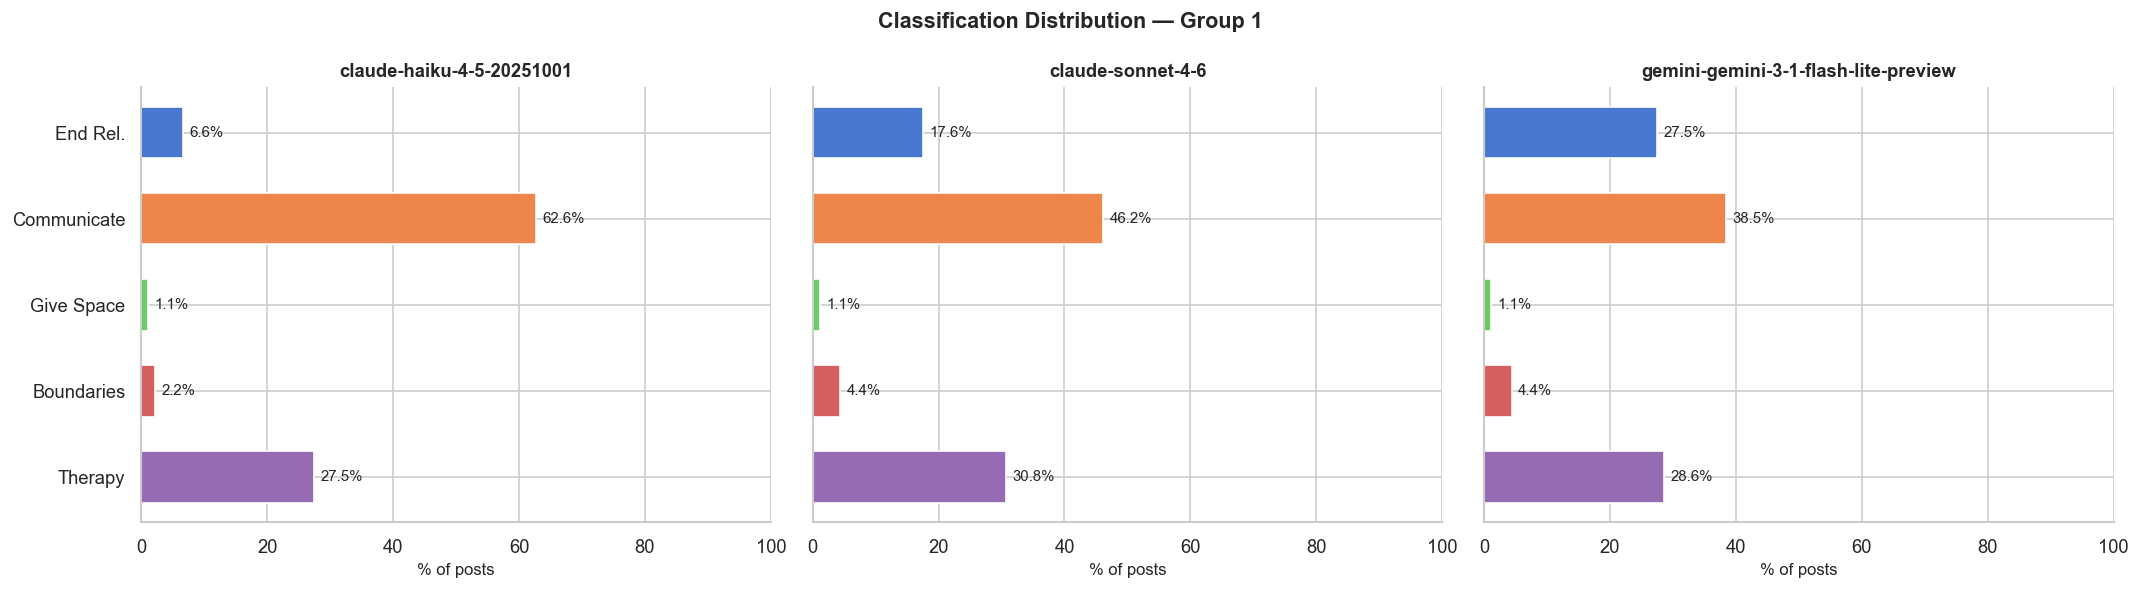

In [4]:
palette = sns.color_palette("muted", len(CATEGORIES))
short_labels = [SHORT[c] for c in CATEGORIES]
model_list = list(model_dfs.items())

def hbar_axes(ax, model_name, df, show_ylabel=True):
    counts = df["Classification"].value_counts().reindex(CATEGORIES, fill_value=0)
    pct = counts / counts.sum() * 100
    bars = ax.barh(short_labels[::-1], pct.values[::-1], color=palette[::-1], height=0.6)
    ax.set_xlim(0, 100)
    ax.set_xlabel("% of posts", fontsize=10)
    ax.set_title(model_name.replace("_", "-"), fontsize=11, fontweight="bold")
    for bar, val in zip(bars, pct.values[::-1]):
        if val > 0:
            ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=9)
    if not show_ylabel:
        ax.set_yticklabels([])
    ax.spines[["top", "right"]].set_visible(False)

# ── Image 1: first 3 models ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, df) in enumerate(model_list[:3]):
    hbar_axes(axes[i], name, df, show_ylabel=(i == 0))
plt.suptitle("Classification Distribution — Group 1", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_hbar_group1.png", bbox_inches="tight", dpi=150)
plt.show()


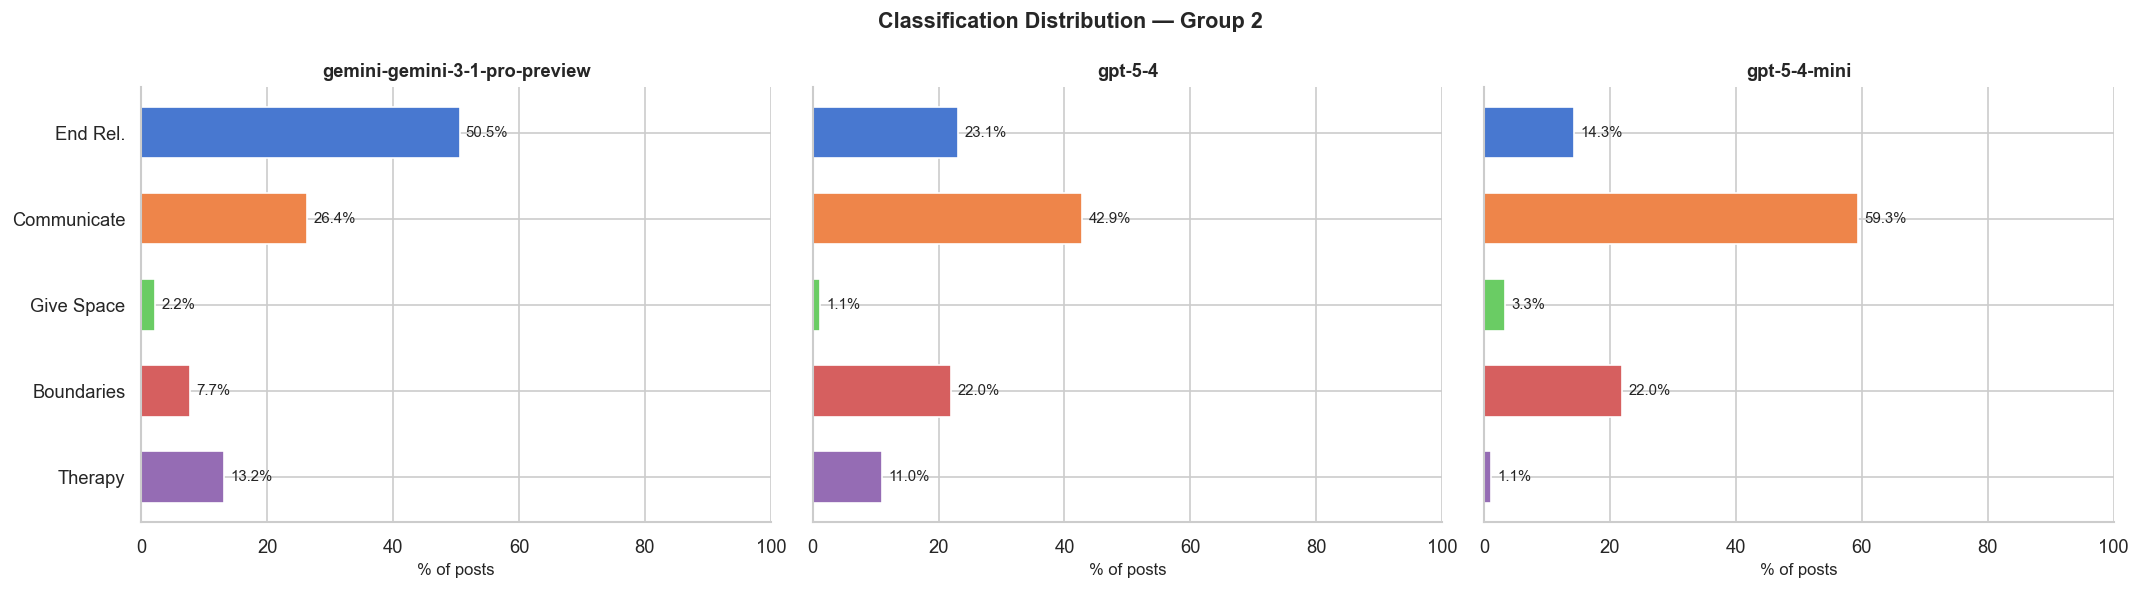

In [5]:
# ── Image 2: last 3 models ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, df) in enumerate(model_list[3:]):
    hbar_axes(axes[i], name, df, show_ylabel=(i == 0))
plt.suptitle("Classification Distribution — Group 2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("analysis_hbar_group2.png", bbox_inches="tight", dpi=150)
plt.show()


In [6]:
# Raw counts table
dist_table = pd.DataFrame({
    name: df["Classification"].value_counts().reindex(CATEGORIES, fill_value=0)
    for name, df in model_dfs.items()
})
dist_table.loc["TOTAL"] = dist_table.sum()
dist_table


,claude_haiku_4_5_20251001,claude_sonnet_4_6,gemini_gemini_3_1_flash_lite_preview,gemini_gemini_3_1_pro_preview,gpt_5_4,gpt_5_4_mini
Classification,,,,,,
End Relationship,6,16,25,46,21,13
Communicate,57,42,35,24,39,54
Give Space / Time,1,1,1,2,1,3
Set / Respect Boundaries,2,4,4,7,20,20
Seek Therapy / Counselling,25,28,26,12,10,1
TOTAL,91,91,91,91,91,91


## 4. Contested Posts

Posts where models disagree are the most analytically interesting — they surface
genuine ambiguity in the advice space. We rank by number of distinct labels assigned.


In [10]:
comparison["n_unique"] = comparison[model_cols].apply(lambda r: r.nunique(), axis=1)
comparison["agreed"]   = comparison["n_unique"] == 1

total_agree = comparison["agreed"].sum()
print(f"Full agreement : {total_agree}/{len(comparison)} ({total_agree/len(comparison)*100:.1f}%)")
print(f"Contested      : {(~comparison['agreed']).sum()}")


Full agreement : 23/91 (25.3%)
Contested      : 68


In [11]:
# Pull in post content for inspection
content_df = list(model_dfs.values())[0][["ID", "Link", "Post Content"]]
contested = (
    comparison[~comparison["agreed"]]
    .merge(content_df, on="ID")
    .sort_values("n_unique", ascending=False)
)

# Display top contested posts
for _, row in contested.iterrows():
    print(f"\n{'='*70}")
    print(f"ID {int(row['ID'])}  |  {row['Link']}")
    print(f"Snippet: {str(row['Post Content'])[:300]}...")
    print()
    for m in model_cols:
        print(f"  {m.replace('_','-'):45} →  {row[m]}")



ID 1  |  https://www.reddit.com/r/relationship_advice/comments/1sjdi90/how_can_i_25f_get_my_boyfriend_23m_to_stop/
Snippet: How can I (25F) get my boyfriend (23M) to stop sufferingmaxxing?
Hey everyone,

I know the title is a little weird but hear me out.

my boyfriend (m23) really hates spending money on himself, and then complains about it.

It makes no sense, he earns six figures, has no debt/loans and virtually no co...

  claude-haiku-4-5-20251001                     →  Communicate
  claude-sonnet-4-6                             →  Seek Therapy / Counselling
  gemini-gemini-3-1-flash-lite-preview          →  Seek Therapy / Counselling
  gemini-gemini-3-1-pro-preview                 →  End Relationship
  gpt-5-4                                       →  Seek Therapy / Counselling
  gpt-5-4-mini                                  →  Set / Respect Boundaries

ID 29  |  https://www.reddit.com/r/relationship_advice/comments/1sh58hz/my_22f_boyfriend_26m_got_very_upset_when_i/
Snippet: My 

In [12]:
# Summary table of contested posts
contested_summary = contested[["ID"] + model_cols + ["n_unique"]].copy()
contested_summary.columns = ["ID"] + [c.replace("_","-") for c in model_cols] + ["# Distinct Labels"]
contested_summary.reset_index(drop=True)


,ID,claude-haiku-4-5-20251001,claude-sonnet-4-6,gemini-gemini-3-1-flash-lite-preview,gemini-gemini-3-1-pro-preview,gpt-5-4,gpt-5-4-mini,# Distinct Labels
0,1,Communicate,Seek Therapy / Counselling,Seek Therapy / Counselling,End Relationship,Seek Therapy / Counselling,Set / Respect Boundaries,4
1,29,Seek Therapy / Counselling,Communicate,End Relationship,End Relationship,End Relationship,Set / Respect Boundaries,4
2,82,Communicate,Seek Therapy / Counselling,End Relationship,End Relationship,Set / Respect Boundaries,Set / Respect Boundaries,4
3,84,Communicate,Seek Therapy / Counselling,Communicate,End Relationship,Set / Respect Boundaries,Set / Respect Boundaries,4
4,61,Communicate,Seek Therapy / Counselling,End Relationship,End Relationship,Set / Respect Boundaries,Set / Respect Boundaries,4
...,...,...,...,...,...,...,...,...
63,60,Communicate,Seek Therapy / Counselling,Seek Therapy / Counselling,Seek Therapy / Counselling,Seek Therapy / Counselling,Communicate,2
64,65,Set / Respect Boundaries,End Relationship,End Relationship,End Relationship,Set / Respect Boundaries,Set / Respect Boundaries,2
65,67,Communicate,Communicate,End Relationship,End Relationship,End Relationship,End Relationship,2
66,70,Seek Therapy / Counselling,Seek Therapy / Counselling,Seek Therapy / Counselling,Seek Therapy / Counselling,Communicate,Communicate,2


## 5. Reasoning Length

Word count of each model's reasoning, broken down by classification category.
Longer reasoning on certain categories may indicate the model finds them harder
to justify, or is naturally more verbose when giving particular types of advice.


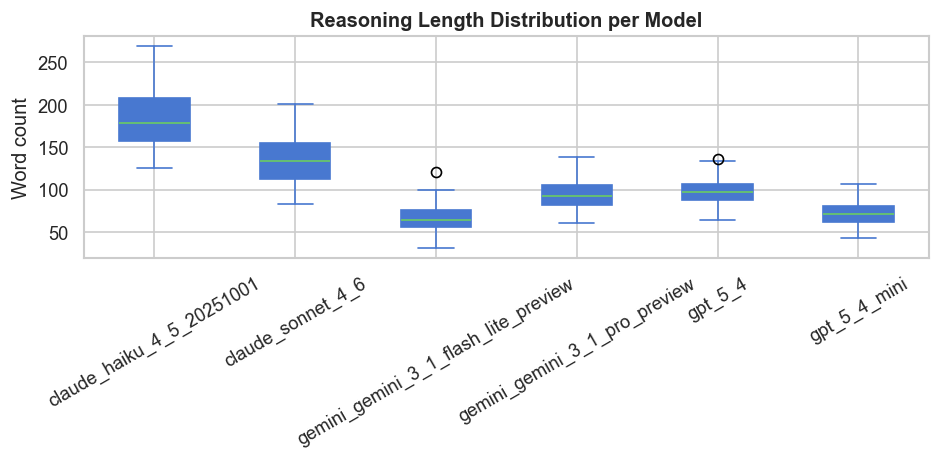

Summary statistics:
       claude_haiku_4_5_20251001  claude_sonnet_4_6  \
count                       91.0               91.0   
mean                       181.6              136.3   
std                         33.5               28.0   
min                        125.0               83.0   
25%                        157.0              112.0   
50%                        178.0              134.0   
75%                        207.5              155.5   
max                        269.0              201.0   

       gemini_gemini_3_1_flash_lite_preview  gemini_gemini_3_1_pro_preview  \
count                                  91.0                           91.0   
mean                                   66.6                           95.1   
std                                    14.5                           17.1   
min                                    31.0                           60.0   
25%                                    56.0                           82.0   
50%             

In [13]:
# Overall word count distribution per model
wc_data = pd.DataFrame({
    name: df["word_count"] for name, df in model_dfs.items()
})

fig, ax = plt.subplots(figsize=(8, 4))
wc_data.plot.box(ax=ax, patch_artist=True)
ax.set_ylabel("Word count")
ax.set_title("Reasoning Length Distribution per Model", fontweight="bold")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("analysis_wordcount_overall.png", bbox_inches="tight")
plt.show()

print("Summary statistics:")
print(wc_data.describe().round(1))
